In [ ]:
import pandas as pd
from pathlib import Path

def readcsv():
    file_path = Path("state.csv")
    return pd.read_csv(file_path if file_path.exists() else "/content/drive/Mydrive/CS240/datasets/state.csv")

References: 
1. Peter Bruce, Andrew Bruce, Peter Gedeck, Practical Statistics for Data Scientists, 2nd Edition.

During these few weeks, we will review important Statistics concepts in Data Science.
According to [Elite Data Science](https://elitedatascience.com/), a data science educational platform, data scientists need to understand the fundamental concepts of **descriptive statistics** and **probability theory**. The **proability theory** includes the key concepts of: 

*   probability distribution
*   statistical significance
*   hypothesis testing
*   regression
*   Bayesian thinking 
    * conditional probability
    * priors and posteriors
    * maximum likelihood

In this notebook, we will first review descriptive statistics.


# Descriptive Statistics (สถิติเชิงพรรณา)

**Descriptive statistics** is a way of analyzing and identifying the basic features of a data set. Descriptive statistics provide *summaries* and *descriptions* of the data, as well as a way to *visualize* the data. 

> **Descriptive statistics** do exactly what it sounds like – they describe the data.

**Types of Descriptive Statistics:**

1.   Measures of Frequency: show how often something occurs
  * ``Count``, ``Percent``, ``Frequency``
  * used when we would like to show how often a response is given
2.   Measures of Central Tendency: locate the distribution by various points
  * ``Mean (ค่าเฉลี่ย)``, ``Median (มัธยฐาน)``, and ``Mode (ฐานนิยม)``
  * used when we would like to show how an average or most commonly indicated response (an estimate of where most of the data is located)
3.   Measures of Dispersion or Variation: identify the spread of scores by stating intervals 
  * ``Range (พิสัย)``, ``Variance (ความแปรปรวน)``, ``Standard Deviation (ส่วนเบี่ยงเบนมาตรฐาน)``
  * ``Range`` = high - low
  * ``Variance`` or ``Standard Deviation`` = difference between observed scores and mean 
  * used when we would like to show how "spread out" the data within a data set are 
  * it is helpful to know when your data are so spread out that it affects the ``mean``
4. Measures of Position: describe how scores fall in relation to one another. 
  * ``Percentile`` ranks, ``Quartile`` ranks
  * relies on standardized scores
  * used when we would like to compare scores to a *normalized score* 



## Estimates of Location: Measures of Central Tendency 
## การวัดแนวโน้มเข้าสู่ศูนย์กลาง

เป็นการหาค่าตัวแทนของชุดข้อมูลซึ่งเป็นค่าที่ข้อมูลทั้งหมดมีแนวโน้มที่จะเข้าใกล้หรือมีค่าใกล้เคียงกับค่านี้ ดังนั้น จึงเรียกว่าเป็น "ค่าศูนย์กลางของข้อมูล" 

A basic step in exploring your data is getting an estimate of where most of the data is located (i.e., its central tendency).

At first glance, summarizing data might seem fairly trivial: just take the *mean* of the data. 

In fact, while the *mean* is easy to compute and expedient to use, it may not always be the best measure for a central value. For this reason, statisticians have developed and promoted several alternative estimates to the mean.

### Mean, Trimmed Mean, and Wighted Mean

The most basic estimate of location is the *mean*, or average value. The *mean* is the sum of all values divided by the number of values. 
Consider the following set of numbers: ``{3, 5, 1, 2}``. The mean is (3 + 5 + 1 + 2) / 4 = 11 / 4 = 2.75. 

The formula to compute the mean for a set of ``n`` values ``x``<sub>1</sub>, ``x``<sub>2</sub>, ..., ``x``<sub>n</sub> is:

![Stat_Mean](https://drive.google.com/uc?export=view&id=1_WUGKYXN1EsDDpQtur3jeDFBW6Ifxx4Z)



---


A *trimmed mean* eliminates the influence of extreme values. The mean is calculated by dropping a fixed number of sorted values at each end and then taking an average of the remaining values.

Representing the sorted values by ``x``<sub>(1)</sub>, ``x``<sub>(2)</sub>,...,``x``<sub>(n)</sub> where ``x``<sub>(1)</sub> is the smallest value and ``x``<sub>(n)</sub> the largest, the formula to compute the trimmed mean with ``p`` smallest and largest values omitted is:



![Stat_Mean_Trimmed](https://drive.google.com/uc?export=view&id=1k1cvX3CyIYP1WKptRH5ngvJ46fjz_LTw)

For example, in international diving the top score and bottom score from five judges are dropped, and the final score is the average of the scores from the three remaining judges. This makes it difficult for a single judge to manipulate the score, perhaps to favor their country’s contestant. 


---

Another type of mean is a *weighted mean*, which we calculate by multiplying each data value ``x``<sub>``i``</sub> by a user-specified weight ``w``<sub>``i``</sub> and dividing their sum by the sum of the weights. 

The formula for a weighted mean is:

![Stat_Mean_Weighted](https://drive.google.com/uc?export=view&id=1Y5NJIwrWHbq8-ORwzzH_GKjviotkka3z)

There are various motivations for using a weighted mean. Some are discussed in the following.

* Some values are intrinsically more variable than others, and highly variable observations are given a lower weight. For example, if we are taking the average from multiple sensors and one of the sensors is less accurate, then we might downweight the data from that sensor.
* The data collected does not equally represent different groups that we are interested in measuring. For example, because of the way an online experiment was conducted, we may not have a set of data that accurately reflects all groups in the user base. To correct that, we can give a lower weight to the values from the groups that were underrepresented.

### Median

The *median* is the middle number on a sorted list of the data. 

* If there is an even number of data values, the *middle value* is the one that is not actually in the data set, but rather the average of the two values that divide the sorted data into upper and lower halves.
* Otherwise, the *middle value* is the one that is exactly at the middle of the sorted set.

> The *median* is **"robust against outliers"** in the data set, whereas the *mean* actually is well-known as **"sensitive to outliers"**.

Consider 5 measurements sent back from 5 sensors within an area: ``142``, ``124``, ``121``, ``151``, ``132``. We assume that ``151`` is a correct value, but that a device failure leads to the false measurement of ``251``.

Let see what will happen to the mean and median of this data set.

Run the following block of code. Notice that the *median* does not alter. However, the *mean* suffers a lot from the errorneous measurement.

In [40]:
import numpy as np
M = [142,124,121,151,132]  # measurements with no error
M_array = np.array(M)
avg1 = np.mean(M_array)
med1 = np.median(M_array)
print("Measurements with no error:")
print("avg = {0}, median = {1}".format(avg1, med1))
print()

M_error = [142,124,121,251,132]  # measurements with an error 151 -> 251
M_error_array = np.array(M_error)
avg2 = np.mean(M_error_array)
med2 = np.median(M_error_array)
print("Measurements with an error:")
print("avg = {0}, median = {1}".format(avg2, med2))

Measurements with no error:
avg = 134.0, median = 132.0

Measurements with an error:
avg = 154.0, median = 132.0


### Example: Location Estimates of Population and Murder Rates

Given the [data set](https://drive.google.com/file/d/1N_luYHffJ-0RGE2PM-rRZvCYCErr4vvk/view?usp=sharing) containing population and murder rates (in units of murders per 100,000 people per year) for each US state (2010 Census). We will explore how to estimate ``location`` of the data using Python.

In [41]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from pathlib import Path

# Table 1-2
file_path = Path("state.csv")
state = pd.read_csv(file_path if file_path.exists() else "/content/drive/MyDrive/Classroom/CS245_64-1 870001_650001/data/Lecture_Week#05/state.csv")

# print the first 8 rows. 
print(state.head(8))
# the data set comprises of xx observations and yy characteristics.
print("\nThe 'shape' (row,col) of the data set is {0}.\n".format(state.shape)) 
# print a brief summary of the data set

state.info()

         State  Population  Murder Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE

The 'shape' (row,col) of the data set is (50, 4).

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     str    
 1   Population    50 non-null     int64  
 2   Murder Rate   50 non-null     float64
 3   Abbreviation  50 non-null     str    
dtypes: float64(1), int64(1), str(2)
memory usage: 1.7 KB


Compute the *mean*, *trimmed mean*, and *median* for Population. For *mean* and *median* we can use the ``pandas`` methods of the ``dataframe``. The *trimmed mean* requires the ``trim_mean()`` function in ``scipy.stats``. 

Notice that the *mean* is bigger than the *trimmed mean*, which in turn is bigger than the *median*.

In [25]:
print("Statistics for 'Population' data in 50 US states:")
print("mean =", end=" ")
print(state['Population'].mean())
print("trimmed mean =", end=" ")
print(trim_mean(state['Population'], 0.1)) # trim=0.1 drops 10% from each end
print("median =", end=" ")
print(state['Population'].median())

Statistics for 'Population' data in 50 US states:
mean = 6162876.3
trimmed mean = 4783697.125
median = 4436369.5


The *weighted mean* is avaiable via ``numpy``.

In [27]:
print("murder rate =", end=" ")
print(state['Murder Rate'].mean())
print("murder rate (weighted by number of populations) =", end=" ")
print(np.average(state['Murder Rate'], weights=state['Population']))
#print("(weighted by the number of populations within each state)")

murder rate = 4.066
murder rate (weighted by number of populations) = 4.445833981123393


## Measures of Position 
## การวัดตำแหน่ง (ของข้อมูลที่สนใจ) 

การบอกลำดับที่ (rank) ของข้อมูลที่เราสนใจเมื่อเปรียบเทียบกับข้อมูลอื่น ๆ ภายในชุดข้อมูล

### Percentile / Quantile

In a data set, the ``P``th ``percentile`` is a value such that at least ``P`` percent of the values take on this value or less and at least ``(100 – P)`` percent of the values take on this value or more. 

For example, to find the ``80``th ``percentile``, sort the data. Then, starting with the smallest value, proceed ``80`` percent of the way to the largest value. 

เปอร์เซ็นไทล์ที่ ``r`` ใด ๆ สามารถคำนวณได้จากสูตรต่อไปนี้



ตำแหน่งภายในชุดข้อมูลของเปอร์เซ็นไทล์ที่ ``r`` ใด ๆ สามารถคำนวณได้จากสูตรต่อไปนี้

เมื่อ ``N`` คือ จำนวนข้อมูลทั้งหมดในชุดข้อมูล
![Stat_Position_Percentile](https://drive.google.com/uc?export=view&id=1HDDHDA7tpAQcgqoNN2uKqjblfkY8KjI_)

<u>ตัวอย่าง</u> สมมติว่ามีข้อมูล 15 ตัว ซึ่งเรียงลำดับจากน้อยไปมาก ดังนี้ ``10, 12, 15, 20, 25, 26, 28, 29, 33, 34, 36, 38, 40, 42, 42`` 

เปอร์เซ็นไทล์ที่ ``15`` อยู่ในตำแหน่งใด? และมีค่าเท่าใด?

จากสูตร ตำแหน่งของเปอร์เซ็นไทล์ที่ ``15`` ของข้อมูลชุดนี้ คือ P<sub>15</sub> = (15/100) x (15 + 1) = 2.4 นั่นคือ ตำแหน่งที่ 2.4 ซึ่งก็คืออยู่ระหว่างข้อมูลตำแหน่งที่สอง (12) และข้อมูลตำแหน่งที่สาม (15) 

และข้อมูลในตำแหน่งที่ 2.4 คำนวณได้จากความสัมพันธ์ต่อไปนี้ 

![Stat_Position_Percentile_Ex](https://drive.google.com/uc?export=view&id=1w9OzqX0RZLkeHIVVQBBNk8Vbayo-bbwf)

<u>ตัวอย่าง</u> จากข้อมูล 15 ตัว ในตัวอย่างก่อนหน้า เปอร์เซ็นไทล์ที่ ``20`` อยู่ในตำแหน่งใด? และมีค่าเท่าใด?

จากสูตร ตำแหน่งของเปอร์เซ็นไทล์ที่ ``20`` ของข้อมูลชุดนี้ คือ P<sub>20</sub> = (20/100) x (15 + 1) = 3.2 นั่นคือ ตำแหน่งที่ 3.2 ซึ่งก็คืออยู่ระหว่างข้อมูลตำแหน่งที่สาม (15) และข้อมูลตำแหน่งที่สี่ (20) 

และข้อมูลในตำแหน่งที่ 3.2 คำนวณได้จากความสัมพันธ์ต่อไปนี้ 

![Stat_Position_Percentile_Ex2](https://drive.google.com/uc?export=view&id=1FHrVdPcx2mxErWoaYVDm8P8V0I6M2OF4)

<u>Note</u> the *median* is the same thing as the ``50``th percentile.

In statistics, the *percentile rank* (PR) of a score is the percentage of scores in its frequency distribution that are less than that score. ยกตัวอย่างเช่น ถ้านักศึกษา A มีคะแนนมากกว่าหรือเท่ากับ 90% ของทั้งคลาส (มีนักศึกษา 90% ที่คะแนนน้อยกว่า A) แสดงว่า ลำดับเปอร์เซ็นไทล์ของคะแนนที่นักศึกษา A ทำได้ คือ 95 นั่นคือ คะแนนของ A อยู่ที่เปอร์เซ็นไทล์ที่ 95   

The mathematical formula for computing the percentile rank is as follows.

![Stat_Position_PercentileRank](https://drive.google.com/uc?export=view&id=1cst8ckG9bNLXVqCtG2SGwDW_ObC_V4DR)

where ``CF`` (cumulative frequency) is the count of all scores less than or equal to the score of interest, ``F`` is the frequency for the score of interest, and ``N`` is the number of scores in the distribution.

<u>ตัวอย่าง</u>: พิจารณาข้อมูลการกระจายของข้อมูลคะแนนนักศึกษา 10 คนในตารางด้านล่าง 

![Stat_Position_PercentileRank_Ex](https://drive.google.com/uc?export=view&id=1GaVyO72Rb-STXzZ8IiB1Z4KW-0U5iE8c)

คะแนน 4 อยู่ที่เปอร์เซ็นไทล์ที่เท่าใด? 

จากสูตรข้างต้น จะได้ว่า 

![Stat_Position_PercentileRank_Ex_วิธีทำ](https://drive.google.com/uc?export=view&id=16PnxqJxMVvMF1DAOULyt73XbixfvnNXz)

<u>Note</u> the *percentile* is essentially the same as a *quantile*, with *quantiles* indexed by fractions (so the ``.8 quantile`` is the same as the ``80th percentile``).

### Example: Position Estimates of Population and Murder Rates

Given the [data set](https://drive.google.com/file/d/1N_luYHffJ-0RGE2PM-rRZvCYCErr4vvk/view?usp=sharing) containing population and murder rates (in units of murders per 100,000 people per year) for each US state (2010 Census). We will explore how to estimate ``position`` of the data using Python.

<u>Note</u>: Both ``numpy`` and ``pandas`` data frame provides methods for calculating and quantiles. However, in Statistics, there are various ways to estimate the quantiles. The default methods used by ``numpy`` and ``pandas`` packages are different. To make the results from both packages correspond to each other, we set the ``interpolation`` parameter of the function ``pandas.DataFrame.quantile()`` to be as: ``interpolation = "lower"``.

---
Printing 25th, 50th, and 75th Percentile of the data set


In [43]:
#print(state)
#print()

# printing 25th, 50th, and 75th Percentile of the Population and Murder Rate data
print("25th, 50th, and 75th Percentile for Population and Murder Rate in 50 US states:")
state.quantile([0.25, 0.5, 0.75])
print()
print(state.quantile([0.25, 0.5, 0.75], interpolation="lower")) # corresponding to the calculation method used by numpy

25th, 50th, and 75th Percentile for Population and Murder Rate in 50 US states:


TypeError: unsupported operand type(s) for -: 'str' and 'str'

---
Compute Percentile Rank (PR) for a particular data point in the data set

To find the percentile of a value relative to an array (or in your case a dataframe column), use ``stats.percentileofscore()`` function in the ``scipy`` package as follows.

In [42]:
import pandas as pd
import numpy as np
from scipy import stats

state = pd.read_csv(Path("state.csv"))

state.set_index("State", inplace=True)   # make 'State' as the explicit index of dataframe
#state

pop_AL = state.loc['Alabama','Population']
pop_AL_Percentile = stats.percentileofscore(state['Population'], pop_AL) # stats.percentileofscore()
mur_AL = state.loc['Alabama','Murder Rate']
mur_AL_Percentile = stats.percentileofscore(state['Murder Rate'], mur_AL) # stats.percentileofscore()
print("Alabama:")
print(state.loc['Alabama'])
print("nth percentile of AL's population  = {0}".format(pop_AL_Percentile))
print("nth percentile of AL's murder rate = {0}".format(mur_AL_Percentile))
print()

print("========================== Verification ==========================")
print("56th Percentile of State population  = {0}".format(state['Population'].quantile(0.56,interpolation='lower')))
print("82th Percentile of State murder rate = {0}".format(state['Murder Rate'].quantile(0.82,interpolation='lower')))

Alabama:
Population      4779736
Murder Rate         5.7
Abbreviation         AL
Name: Alabama, dtype: object
nth percentile of AL's population  = 56.0
nth percentile of AL's murder rate = 82.0

========================== Verification ==========================
56th Percentile of State population  = 4779736
82th Percentile of State murder rate = 5.7


## Estimates of Variability: Measures of Dispersion
## การวัดการกระจาย

เป็นการวัดการกระจายของข้อมูลภายในชุดข้อมูล กล่าวคือ วัดว่าข้อมูลภายในชุดมีค่าใกล้เคียงกัน (เกาะกลุ่มกัน) หรือ มีค่าที่แตกต่างกันมาก

**Location** is just one dimension in summarizing a feature. Now, we would explore the second dimension, **variability**, also referred to as dispersion, measures whether the data values are tightly clustered or spread out. 

การใช้เฉพาะค่าตัวแทนของข้อมูล (mean/median/mode) ในการอธิบายชุดข้อมูลอาจไม่ใช่ทางเลือกที่เหมาะสมในทุกสถานการณ์ 

ลองพิจารณาข้อมูล 3 ชุด ที่แสดงด้านล่าง 
สังเกตว่า ข้อมูลทั้งสามชุดมีค่าเฉลี่ยและค่ามัธยฐานเท่ากัน อย่างไรก็ตาม ลักษณะของข้อมูลภายในแต่ละชุดมีความแตกต่างกันชัดเจน 

|  DataSet#1  |  DataSet#2  |  DataSet#3  |
|:-----------:|:-----------:|:-----------:|
|     30      |     10      |     10      |
|     30      |     30      |     20      |
|     30      |     30      |     30      |
|     30      |     30      |     40      |
|     30      |     50      |     50      |
|-------------|-------------|-------------|
|  mean=30    |  mean=30    |  mean=30    |
|  median=30  |  median=30  |  median=30  |
|-------------|-------------|-------------|

**Variability** lies at the heart of Statistics: measuring it, reducing it, distinguishing random from real variability, identifying the various sources of real variability, and making decisions in the presence of it.

---
Deviation (ส่วนเบี่ยงเบน)

The most widely used estimates of variation are based on the differences, or deviations, between the estimate of location and the observed data. 

For a set of data ``{1, 4, 4}``, the mean is ``3`` and the median is ``4``. 

The deviations from the *mean* are the differences: ``1 – 3 = –2``, ``4 – 3 = 1``, ``4 – 3 = 1``. These deviations tell us how dispersed the data is around the central value.


### Variance (ความแปรปรวน) and Standard Deviation (ส่วนเบี่ยงเบนมาตรฐาน)

The best-known estimates of variability are the *variance* and the *standard deviation*, which are based on "squared deviations". The *variance* is an average of the squared deviations, and the standard deviation is the square root of the variance:

![Stat_Variability_Variance_StandardDeviation](https://drive.google.com/uc?export=view&id=11N6murBnKd8_TdJ1gdN8AJ9qSWiNGfA-)

### Range (พิสัย)

A different approach to estimating dispersion is based on looking at the spread of the sorted data. Statistics based on sorted (ranked) data are referred to as **order statistics**. 

The most basic measure is the *range*: the difference between the largest and smallest numbers. 

<u>Note</u>: Knowing the minimum and maximum values of a data set could be useful, but the *range* is extremely sensitive to outliers and not very useful as a general measure of dispersion in the data.

### Inter-Quartile Range (IQR)

A common measurement of variability is the difference between the ``25``th percentile and the ``75``th percentile, called the *interquartile range* (or IQR).

<u>ตัวอย่าง</u> ชุดข้อมูล ``3, 1, 5, 3, 6, 7, 2, 9`` เมื่อนำมาเรียงลำดับจากน้อยไปมาก ``1, 2, 3, 3, 5, 6, 7, 9``
จะได้ 25th percentile = 2.5 และ 75th percentile = 6.5 
ดังนั้น IQR = 6.5 – 2.5 = 4  


### Example: Variability Estimates of Population and Murder Rates

Given the [data set](https://drive.google.com/file/d/1N_luYHffJ-0RGE2PM-rRZvCYCErr4vvk/view?usp=sharing) containing population and murder rates (in units of murders per 100,000 people per year) for each US state (2010 Census). We will explore how to estimate ``position`` of the data using Python.

In [44]:
import pandas as pd
import numpy as np

state = pd.read_csv(Path("state.csv"))

print("50 US states Population:")
print("\tStandard deviation =", end = " ")
print(state['Population'].std())

print("\tVariance =", end = " ")
print(state['Population'].var())

print("\tInter-Quatile Range (IQR) =", end = " ")
print(state['Population'].quantile(0.75) - state['Population'].quantile(0.25))

print()

print("50 US states Murder Rate (units per 100,000 people per year):")
print("\tStandard deviation =", end = " ")
print(state['Murder Rate'].std())

print("\tVariance =", end = " ")
print(state['Murder Rate'].var())

print("\tInter-Quatile Range (IQR) =", end = " ")
print(state['Murder Rate'].quantile(0.75) - state['Murder Rate'].quantile(0.25))

50 US states Population:
	Standard deviation = 6848235.347401142
	Variance = 46898327373394.445
	Inter-Quatile Range (IQR) = 4847308.0

50 US states Murder Rate (units per 100,000 people per year):
	Standard deviation = 1.9157361243029227
	Variance = 3.6700448979591838
	Inter-Quatile Range (IQR) = 3.125


---
Percentiles and Boxplots

Murder Rate data:

The median is ``4`` murders per 100,000 people, although there is quite a bit of variability: the ``5th`` percentile is only ``1.6`` and the ``95th`` percentile is ``6.51``.

Boxplots, introduced by Tukey [Tukey-1977], are based on percentiles and give a quick way to visualize the distribution of data. The figure shown below explains various information illustrated by Boxplots.

![Stat_Position_Boxplot](https://drive.google.com/uc?export=view&id=1em4YRXtHvf24lni0fzUzEKrjTRVbtm0F)

In [45]:
import pandas as pd
import numpy as np

file_path = Path("state.csv")
state = pd.read_csv(file_path if file_path.exists() else "/content/drive/MyDrive/Classroom/CS245_64-1 870001_650001/data/Lecture_Week#05/state.csv")
state['Murder Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder Rate, dtype: float64

In [ ]:
%matplotlib inline
import matplotlib.pylab as plt

ax = (state['Population']/1000000).plot.box(figsize=(3, 4))
ax.set_ylabel('Population (millions)')

plt.tight_layout()
plt.show()

![Stat_Variability_Boxplot_Population](https://drive.google.com/uc?export=view&id=1XF-6-NiMsTaBlUuSAWGd2A5i7vqlm7C4)

## Measures of Frequency 
## การวัดความถี่ของข้อมูล

### Frequency and Cumulative Frequency  

---
Count the frequency of every unique value within a dataframe


In [46]:
import pandas as pd
import numpy as np

mylist1 = ['N','N','C','N','S',
           'N','N','S','N','N', 
           'N','S','N','C','N',
           'N','N','N','S','N']
df1 = pd.DataFrame(mylist1)
df1.value_counts() # count unique values 

0
N    14
S     4
C     2
Name: count, dtype: int64

In [ ]:
state['State'].value_counts()         # count unique values within 'Series' 
state['Abbreviation'].value_counts()  # count unique values within 'Series' 

---
Compute the cumulative frequency 


In [ ]:
mylist2 = [1, 2, 3, 3, 3,
           4, 4, 5, 5, 7]
df2 = pd.DataFrame(mylist2)
df2 = pd.DataFrame(df2.value_counts(), columns=['Freq'])  
df2.index.rename('Data', inplace=True)
df2.reset_index(inplace=True)
df2.loc[6] = [6, 0]  # adding a new row for data = 6, freq = 0
df2.sort_values('Data', inplace=True)
df2.reset_index(drop=True, inplace=True)
df2['CumFreq'] = df2['Freq'].cumsum()
df2

,Data,Freq,CumFreq
0,1,1,1
1,2,1,2
2,3,3,5
3,4,2,7
4,5,2,9
5,6,0,9
6,7,1,10


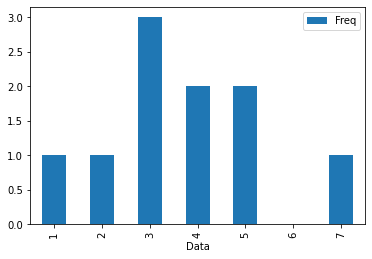

In [ ]:
df2.plot.bar(x='Data', y='Freq')

### Frequency Tables and Histograms  

---
Frequency Tables

A *frequency table* of a variable divides up the variable range into equally spaced segments and tells us how many values fall within each segment. 

The function ``pandas.cut()`` creates a series that maps the values into the segments. Using the method ``value_counts()``, we get the *frequency table*:

In [ ]:
binnedPopulation = pd.cut(state['Population'], 10) # dividing the Series into 10 equal-sized segments
print(binnedPopulation.value_counts())

---
Histogram

The ``pandas`` package supports histograms for data frames with the ``DataFrame.plot.hist()`` method. Use the keyword argument ``bins`` to define the number of bins. The various plot methods return an axis object that allows further fine-tuning of the visualization using Matplotlib:

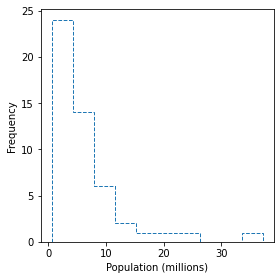

In [ ]:
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4), histtype='step',linestyle='dashed') # use default value for 'bins' = 10
ax.set_xlabel('Population (millions)')

plt.tight_layout()
plt.show()

---
<u>Note</u> that the ``pandas.DataFrame.describe()`` function is very handy in giving various summary statistics at once. 

In [ ]:
state.describe()
state.describe(include='all') 